In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import os 
os.listdir()

['classic_cookie_texture_dataset.csv',
 '01_data_audit.ipynb',
 '02_texture_analysis.ipynb']

In [5]:
classic_cookie_recipe_level = pd.read_csv(
    "classic_cookie_texture_dataset.csv"
)

In [6]:
classic_cookie_recipe_level.shape

(594, 24)

In [7]:
classic_cookie_recipe_level.head()

,RecipeId,Name,RecipeIngredientParts,RecipeInstructions,num_reviews,avg_rating,all_reviews,chewy,chewier,crispy,...,cakey,cake_like,thick,thin,flat,spread,spreading,dry,moist,dense
0,3307,Mrs. Fields Chocolate Chip Cookies,['all-purpose flour' 'baking soda' 'salt' 'dar...,"['Heat oven to 300°F.'\n 'Combine flour, bakin...",8,2.250000,"dough is too thin, the cookies melted together...",0,0,0,...,0,0,0,1,1,1,0,0,0,0
1,3599,Best Basic Chocolate Chip Cookies,['shortening' 'butter' 'brown sugar' 'granulat...,['Thin-and-Crispy: Bake 10-12 min per batch.'\...,11,4.090909,"These were really good! I made the ""basic"" (n...",0,0,0,...,0,1,0,1,1,0,0,0,0,0
2,4050,Canadian Living's Best Chocolate Chip Cookies,['butter' 'shortening' 'granulated sugar' 'bro...,"['In a large bowl, cream together butter and s...",82,4.390244,Very good classic chocolate chip cookie. Not ...,1,0,1,...,0,0,1,1,1,1,1,1,1,0
3,4051,Mike's Grand Marnier Chocolate Chip Cookies,['margarine' 'brown sugar' 'granulated sugar' ...,"['Cream margarine, sugars, vanilla and Grand M...",2,4.000000,"This makes a lovely chocolate chip cookie, but...",0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4092,Chocolate Chip Cookies,['butter' 'caster sugar' 'brown sugar' 'egg' '...,['Set the oven to 190°C/375°F/Gas 5.'\n 'Beat ...,8,4.625000,I don't bake many cookies but these were enjoy...,0,0,0,...,0,0,0,1,0,1,0,0,0,0


# 1. Analyze Ingredients

In [13]:
texture_cols = [
    "chewy",
    "chewier",
    "crispy",
    "crisp",
    "crunchy",
    "soft",
    "gooey",
    "cakey",
    "cake_like",
    "thick",
    "thin",
    "flat",
    "spread",
    "spreading",
    "dry",
    "moist",
    "dense"
]

texture_counts = (
    classic_cookie_recipe_level[texture_cols]
    .sum()
    .sort_values(ascending=False)
)

texture_counts

thin         270
soft         218
chewy        215
crisp        169
flat         138
crispy       113
spread       101
dry           75
moist         74
thick         66
crunchy       64
gooey         39
cakey         38
spreading     20
cake_like     19
dense         18
chewier       16
dtype: int64

In [14]:
classic_cookie_recipe_level[classic_cookie_recipe_level["chewy"] == 1][
    "RecipeIngredientParts"
].head()

2    ['butter' 'shortening' 'granulated sugar' 'bro...
5    ['margarine' 'butter flavor shortening' 'brown...
6    ['butter' 'margarine' 'sugar' 'brown sugar' 'e...
7    ['margarine' 'white sugar' 'brown sugar' 'flou...
8    ['butter' 'sugar' 'light brown sugar' 'eggs' '...
Name: RecipeIngredientParts, dtype: str

In [15]:
cookie_texture_recipes = pd.read_csv(
    "classic_cookie_texture_dataset.csv"
)

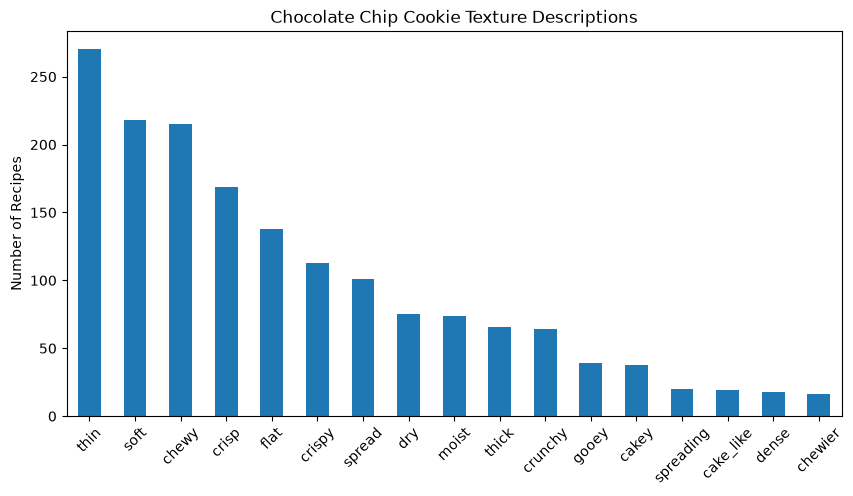

In [16]:
import matplotlib.pyplot as plt

texture_counts.plot(
    kind="bar",
    figsize=(10,5)
)

plt.ylabel("Number of Recipes")
plt.title("Chocolate Chip Cookie Texture Descriptions")
plt.xticks(rotation=45)
plt.show()

In [17]:
classic_cookie_recipe_level[
    "RecipeIngredientParts"
].iloc[0]

"['all-purpose flour' 'baking soda' 'salt' 'dark brown sugar' 'sugar'\n 'butter' 'eggs' 'vanilla extract']"

In [18]:
ingredient_terms = [
    "butter",
    "shortening",
    "margarine",
    "brown sugar",
    "granulated sugar",
    "egg",
    "cornstarch",
    "baking soda",
    "baking powder",
    "vanilla",
    "flour",
    "oat"
]


for ingredient in ingredient_terms:
    classic_cookie_recipe_level[ingredient.replace(" ","_")] = (
        classic_cookie_recipe_level["RecipeIngredientParts"]
        .str.lower()
        .str.contains(ingredient)
        .astype(int)
    )

In [19]:
chewy_cookies = classic_cookie_recipe_level[
    classic_cookie_recipe_level["chewy"] == 1
]


chewy_cookies[
    [
        "butter",
        "shortening",
        "brown_sugar",
        "cornstarch",
        "egg"
    ]
].mean()

butter         0.790698
shortening     0.200000
brown_sugar    0.958140
cornstarch     0.023256
egg            0.906977
dtype: float64

In [20]:
pd.crosstab(
    classic_cookie_recipe_level["chewy"],
    classic_cookie_recipe_level["soft"]
)

soft,0,1
chewy,,
0,304,75
1,72,143


In [21]:
pd.crosstab(
    classic_cookie_recipe_level["chewy"],
    classic_cookie_recipe_level["soft"],
    normalize="index"
)

soft,0,1
chewy,,
0,0.802111,0.197889
1,0.334884,0.665116


In [22]:
ingredient_cols = [
    "butter",
    "shortening",
    "brown_sugar",
    "granulated_sugar",
    "egg",
    "cornstarch",
    "baking_soda",
    "baking_powder",
    "vanilla",
    "flour"
]


classic_cookie_recipe_level.groupby("chewy")[ingredient_cols].mean().T

chewy,0,1
butter,0.730871,0.790698
shortening,0.145119,0.200000
brown_sugar,0.828496,0.958140
granulated_sugar,0.277045,0.293023
egg,0.854881,0.906977
cornstarch,0.010554,0.023256
baking_soda,0.844327,0.916279
baking_powder,0.184697,0.213953
vanilla,0.891821,0.958140
flour,0.934037,0.981395


In [27]:
thin_cookies = classic_cookie_recipe_level[
    classic_cookie_recipe_level["thin"] == 1
]

In [28]:
thin_cookies.shape

(270, 37)

In [29]:
thin_cookies[
    [
        "butter",
        "shortening",
        "brown_sugar",
        "granulated_sugar",
        "egg",
        "cornstarch",
        "baking_soda",
        "baking_powder",
        "vanilla",
        "flour"
    ]
].mean()

butter              0.770370
shortening          0.162963
brown_sugar         0.892593
granulated_sugar    0.285185
egg                 0.877778
cornstarch          0.025926
baking_soda         0.888889
baking_powder       0.185185
vanilla             0.937037
flour               0.959259
dtype: float64

In [30]:
classic_cookie_recipe_level.groupby("thin")[
    [
        "butter",
        "shortening",
        "brown_sugar",
        "granulated_sugar",
        "egg",
        "cornstarch",
        "baking_soda",
        "baking_powder"
    ]
].mean().T

thin,0,1
butter,0.737654,0.770370
shortening,0.166667,0.162963
brown_sugar,0.861111,0.892593
granulated_sugar,0.280864,0.285185
egg,0.870370,0.877778
cornstarch,0.006173,0.025926
baking_soda,0.854938,0.888889
baking_powder,0.203704,0.185185


In [31]:
soft_cookies = classic_cookie_recipe_level[
    classic_cookie_recipe_level["soft"] == 1
]

In [32]:
soft_cookies[
    [
        "butter",
        "shortening",
        "brown_sugar",
        "granulated_sugar",
        "egg",
        "cornstarch",
        "baking_soda",
        "baking_powder"
    ]
].mean()

butter              0.784404
shortening          0.201835
brown_sugar         0.935780
granulated_sugar    0.279817
egg                 0.922018
cornstarch          0.022936
baking_soda         0.908257
baking_powder       0.211009
dtype: float64

In [33]:
classic_cookie_recipe_level.groupby("soft")[
    [
        "butter",
        "shortening",
        "brown_sugar",
        "granulated_sugar",
        "egg",
        "cornstarch",
        "baking_soda",
        "baking_powder"
    ]
].mean().T

soft,0,1
butter,0.734043,0.784404
shortening,0.143617,0.201835
brown_sugar,0.840426,0.935780
granulated_sugar,0.284574,0.279817
egg,0.845745,0.922018
cornstarch,0.010638,0.022936
baking_soda,0.848404,0.908257
baking_powder,0.186170,0.211009


In [34]:
thick_cookies = classic_cookie_recipe_level[
    classic_cookie_recipe_level["thick"] == 1
]

In [35]:
thick_cookies[
    [
        "butter",
        "shortening",
        "brown_sugar",
        "granulated_sugar",
        "egg",
        "cornstarch",
        "baking_soda",
        "baking_powder"
    ]
].mean()

butter              0.803030
shortening          0.227273
brown_sugar         0.969697
granulated_sugar    0.227273
egg                 0.909091
cornstarch          0.015152
baking_soda         0.954545
baking_powder       0.181818
dtype: float64

In [36]:
classic_cookie_recipe_level.groupby("thick")[
    [
        "butter",
        "shortening",
        "brown_sugar",
        "granulated_sugar",
        "egg",
        "cornstarch",
        "baking_soda",
        "baking_powder"
    ]
].mean().T

thick,0,1
butter,0.746212,0.803030
shortening,0.157197,0.227273
brown_sugar,0.863636,0.969697
granulated_sugar,0.289773,0.227273
egg,0.869318,0.909091
cornstarch,0.015152,0.015152
baking_soda,0.859848,0.954545
baking_powder,0.196970,0.181818


In [37]:
texture_comparison = pd.DataFrame({
    "chewy": classic_cookie_recipe_level[classic_cookie_recipe_level["chewy"] == 1][
        ["butter","shortening","brown_sugar","granulated_sugar","egg","baking_soda","baking_powder"]
    ].mean(),

    "soft": classic_cookie_recipe_level[classic_cookie_recipe_level["soft"] == 1][
        ["butter","shortening","brown_sugar","granulated_sugar","egg","baking_soda","baking_powder"]
    ].mean(),

    "thin": classic_cookie_recipe_level[classic_cookie_recipe_level["thin"] == 1][
        ["butter","shortening","brown_sugar","granulated_sugar","egg","baking_soda","baking_powder"]
    ].mean(),

    "thick": classic_cookie_recipe_level[classic_cookie_recipe_level["thick"] == 1][
        ["butter","shortening","brown_sugar","granulated_sugar","egg","baking_soda","baking_powder"]
    ].mean()
})

texture_comparison

,chewy,soft,thin,thick
butter,0.790698,0.784404,0.770370,0.803030
shortening,0.200000,0.201835,0.162963,0.227273
brown_sugar,0.958140,0.935780,0.892593,0.969697
granulated_sugar,0.293023,0.279817,0.285185,0.227273
egg,0.906977,0.922018,0.877778,0.909091
baking_soda,0.916279,0.908257,0.888889,0.954545
baking_powder,0.213953,0.211009,0.185185,0.181818


In [38]:
texture_differences = texture_comparison.subtract(
    texture_comparison.mean(axis=1),
    axis=0
)

texture_differences

,chewy,soft,thin,thick
butter,0.003572,-0.002722,-0.016755,0.015905
shortening,0.001982,0.003817,-0.035055,0.029255
brown_sugar,0.019087,-0.003272,-0.046460,0.030645
granulated_sugar,0.021699,0.008492,0.013861,-0.044052
egg,0.003011,0.018052,-0.026188,0.005125
baking_soda,-0.000714,-0.008736,-0.028104,0.037553
baking_powder,0.015962,0.013018,-0.012806,-0.016173


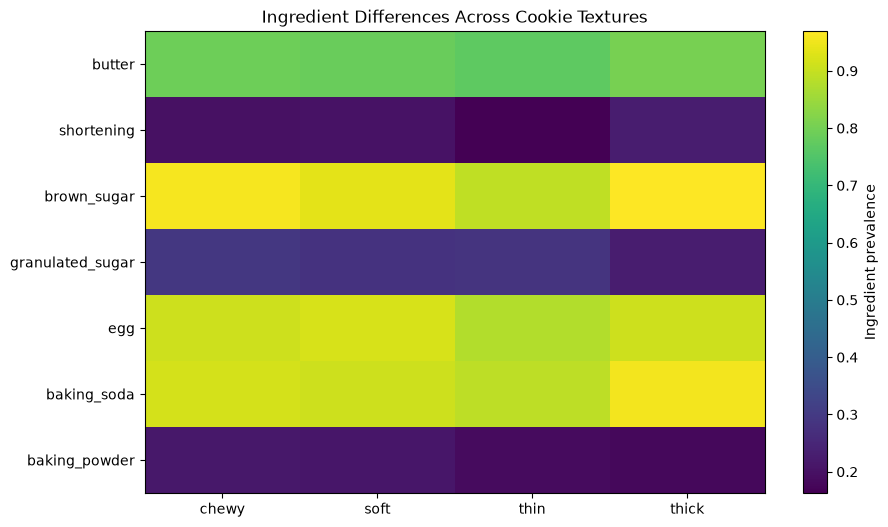

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.imshow(texture_comparison, aspect="auto")

plt.xticks(
    range(len(texture_comparison.columns)),
    texture_comparison.columns
)

plt.yticks(
    range(len(texture_comparison.index)),
    texture_comparison.index
)

plt.colorbar(label="Ingredient prevalence")

plt.title("Ingredient Differences Across Cookie Textures")

plt.show()

## Ingredient Analysis: Relationship Between Ingredients and Cookie Texture

To understand how ingredient choices influence cookie texture, ingredient prevalence was compared across recipes labeled with different texture characteristics.

For each texture category, ingredient prevalence was calculated as the percentage of recipes containing each ingredient. These percentages were then compared between recipes with and without each texture label to identify ingredients associated with different cookie outcomes.

The analysis focused on common cookie structure ingredients:
- Butter
- Shortening
- Brown sugar
- Granulated sugar
- Eggs
- Cornstarch
- Baking soda
- Baking powder


## Overall Ingredient Patterns

The majority of classic chocolate chip cookies contained the core ingredients expected in cookie formulations:

- Flour appeared in nearly all recipes (~96-98%)
- Eggs appeared in most recipes (~85-92%)
- Butter appeared in approximately 77-80% of recipes
- Brown sugar appeared in approximately 83-97% of recipes
- Baking soda appeared in approximately 85-95% of recipes

Because these ingredients are common across nearly all recipes, differences between textures were relatively small. However, several patterns emerged.


## Brown Sugar is Associated with Chewier and Thicker Cookies

Brown sugar showed one of the strongest relationships with texture differences.

Compared with other textures:

- Chewy cookies had slightly higher brown sugar prevalence (+1.9 percentage points)
- Thick cookies had the highest brown sugar prevalence (+3.1 percentage points)
- Thin cookies had lower brown sugar prevalence (-4.6 percentage points)

This aligns with baking science because brown sugar contains molasses, which adds moisture and promotes a softer, chewier texture. Lower brown sugar levels generally reduce moisture retention and can contribute to thinner, crisper cookies.


## Shortening is Associated with Thicker Cookies

Shortening showed a stronger relationship with thick cookies:

- Thick cookies had higher shortening prevalence (+2.9 percentage points)
- Thin cookies had lower shortening prevalence (-3.5 percentage points)

Shortening contains no water and has a higher melting point than butter, which can reduce spread during baking. This can help cookies maintain a thicker shape.


## Chewy Cookies Showed a Combination of Moisture-Retaining Ingredients

Chewy cookies showed slightly higher prevalence of:

- Brown sugar (+1.9 percentage points)
- Granulated sugar (+2.2 percentage points)
- Cornstarch (+1.6 percentage points)

These ingredients can contribute to moisture retention and a softer interior.

However, because most cookie recipes already contain these ingredients, the differences were modest, suggesting that chewy texture likely depends on additional factors such as ingredient ratios, baking time, and cooling methods.


## Thin Cookies Showed Fewer Moisture-Retaining Characteristics

Thin cookies generally showed lower prevalence of ingredients associated with thickness and moisture:

- Brown sugar (-4.6 percentage points)
- Shortening (-3.5 percentage points)
- Egg (-2.6 percentage points)
- Baking soda (-2.8 percentage points)

Rather than being defined by a unique ingredient, thin cookies may result from differences in ingredient ratios and baking conditions that encourage more spreading.


## Thick Cookies Had the Strongest Ingredient Pattern

Thick cookies showed the clearest ingredient differences:

Higher prevalence:
- Brown sugar (+3.1 percentage points)
- Shortening (+2.9 percentage points)
- Butter (+1.6 percentage points)
- Baking soda (+3.8 percentage points)

These ingredients may contribute to maintaining structure and reducing excessive spread.


## Limitations of Ingredient Presence Analysis

Ingredient presence alone does not fully explain cookie texture because most chocolate chip cookie recipes contain the same basic components.

Texture is likely influenced more strongly by:

1. Ingredient ratios
   - Flour-to-fat ratio
   - Sugar-to-flour ratio
   - Brown sugar-to-white sugar ratio
   - Egg-to-flour ratio

2. Processing methods
   - Dough chilling or freezing
   - Butter temperature
   - Mixing method
   - Creaming vs melted butter

3. Baking conditions
   - Oven temperature
   - Baking time
   - Cooling method

Future analysis will examine recipe ratios and preparation techniques to better understand the drivers of cookie texture.

# 2. Analyze ingredient Ratios

In [42]:
classic_cookie_recipe_level.columns

Index(['RecipeId', 'Name', 'RecipeIngredientParts', 'RecipeInstructions',
       'num_reviews', 'avg_rating', 'all_reviews', 'chewy', 'chewier',
       'crispy', 'crisp', 'crunchy', 'soft', 'gooey', 'cakey', 'cake_like',
       'thick', 'thin', 'flat', 'spread', 'spreading', 'dry', 'moist', 'dense',
       'butter', 'shortening', 'margarine', 'brown_sugar', 'granulated_sugar',
       'egg', 'cornstarch', 'baking_soda', 'baking_powder', 'vanilla', 'flour',
       'oat', 'spreads'],
      dtype='str')

In [48]:
import os

for root, dirs, files in os.walk("/Users/abbygoblick/.cache"):
    for file in files:
        if file == "recipes.parquet":
            print(os.path.join(root, file))

/Users/abbygoblick/.cache/kagglehub/datasets/irkaal/foodcom-recipes-and-reviews/versions/2/recipes.parquet


In [49]:
recipes_path = "/Users/abbygoblick/.cache/kagglehub/datasets/irkaal/foodcom-recipes-and-reviews/versions/2/recipes.parquet"
recipes = pd.read_parquet(recipes_path)

In [50]:
recipes.shape

(522517, 28)

In [51]:
recipes.columns.tolist()

['RecipeId',
 'Name',
 'AuthorId',
 'AuthorName',
 'CookTime',
 'PrepTime',
 'TotalTime',
 'DatePublished',
 'Description',
 'Images',
 'RecipeCategory',
 'Keywords',
 'RecipeIngredientQuantities',
 'RecipeIngredientParts',
 'AggregatedRating',
 'ReviewCount',
 'Calories',
 'FatContent',
 'SaturatedFatContent',
 'CholesterolContent',
 'SodiumContent',
 'CarbohydrateContent',
 'FiberContent',
 'SugarContent',
 'ProteinContent',
 'RecipeServings',
 'RecipeYield',
 'RecipeInstructions']

In [52]:
classic_cookie_recipe_level = classic_cookie_recipe_level.merge(
    recipes[
        [
            "RecipeId",
            "RecipeIngredientQuantities"
        ]
    ],
    on="RecipeId",
    how="left"
)

In [53]:
classic_cookie_recipe_level[
    [
        "Name",
        "RecipeIngredientParts",
        "RecipeIngredientQuantities"
    ]
].head()

,Name,RecipeIngredientParts,RecipeIngredientQuantities
0,Mrs. Fields Chocolate Chip Cookies,['all-purpose flour' 'baking soda' 'salt' 'dar...,"[1, 1⁄2, 1⁄4, 1, 1⁄2, 1, 2, 2, 1]"
1,Best Basic Chocolate Chip Cookies,['shortening' 'butter' 'brown sugar' 'granulat...,"[1⁄2, 1⁄2, 1, 1⁄2, 1⁄2, 1⁄4, 2, 1, 2 1⁄2, 1 1⁄..."
2,Canadian Living's Best Chocolate Chip Cookies,['butter' 'shortening' 'granulated sugar' 'bro...,"[1⁄2, 1⁄2, 1, 1⁄2, 2, 2, 2, 1, 1⁄2, 2, 1]"
3,Mike's Grand Marnier Chocolate Chip Cookies,['margarine' 'brown sugar' 'granulated sugar' ...,"[1, 3⁄4, 1⁄2, 1, 4, 2, 2, 1, 1, 2]"
4,Chocolate Chip Cookies,['butter' 'caster sugar' 'brown sugar' 'egg' '...,"[115, 70, 70, 1, 1⁄2, 140, 1⁄4, 1⁄2, 175]"


In [54]:
classic_cookie_recipe_level = classic_cookie_recipe_level.merge(
    recipes[
        [
            "RecipeId",
            "RecipeIngredientQuantities",
            "RecipeIngredientParts"
        ]
    ],
    on="RecipeId",
    how="left",
    suffixes=("", "_original")
)

In [55]:
classic_cookie_recipe_level[
    [
        "Name",
        "RecipeIngredientParts",
        "RecipeIngredientQuantities"
    ]
].head()

,Name,RecipeIngredientParts,RecipeIngredientQuantities
0,Mrs. Fields Chocolate Chip Cookies,['all-purpose flour' 'baking soda' 'salt' 'dar...,"[1, 1⁄2, 1⁄4, 1, 1⁄2, 1, 2, 2, 1]"
1,Best Basic Chocolate Chip Cookies,['shortening' 'butter' 'brown sugar' 'granulat...,"[1⁄2, 1⁄2, 1, 1⁄2, 1⁄2, 1⁄4, 2, 1, 2 1⁄2, 1 1⁄..."
2,Canadian Living's Best Chocolate Chip Cookies,['butter' 'shortening' 'granulated sugar' 'bro...,"[1⁄2, 1⁄2, 1, 1⁄2, 2, 2, 2, 1, 1⁄2, 2, 1]"
3,Mike's Grand Marnier Chocolate Chip Cookies,['margarine' 'brown sugar' 'granulated sugar' ...,"[1, 3⁄4, 1⁄2, 1, 4, 2, 2, 1, 1, 2]"
4,Chocolate Chip Cookies,['butter' 'caster sugar' 'brown sugar' 'egg' '...,"[115, 70, 70, 1, 1⁄2, 140, 1⁄4, 1⁄2, 175]"


In [57]:
def get_ingredient_amount(parts, quantities, ingredient):
    try:
        for part, qty in zip(parts, quantities):
            if ingredient in part.lower():
                return qty
    except:
        return None
    return 0

In [58]:
classic_cookie_recipe_level["butter_amount"] = classic_cookie_recipe_level.apply(
    lambda x: get_ingredient_amount(
        x["RecipeIngredientParts"],
        x["RecipeIngredientQuantities"],
        "butter"
    ),
    axis=1
)

In [59]:
classic_cookie_recipe_level[
    ["Name", "butter_amount"]
].head(10)

,Name,butter_amount
0,Mrs. Fields Chocolate Chip Cookies,0
1,Best Basic Chocolate Chip Cookies,0
2,Canadian Living's Best Chocolate Chip Cookies,0
3,Mike's Grand Marnier Chocolate Chip Cookies,0
4,Chocolate Chip Cookies,0
5,Decadent Chocolate Chip Cookies,0
6,Crispy Chewy Chocolate Chip Cookies,0
7,Best Ever Chocolate Chip Cookies,0
8,Soft Batch Chocolate Chip Cookies,0
9,The Ultimate Chocolate Chip Cookies!,0


In [60]:
classic_cookie_recipe_level.loc[0, "RecipeIngredientParts"]

"['all-purpose flour' 'baking soda' 'salt' 'dark brown sugar' 'sugar'\n 'butter' 'eggs' 'vanilla extract']"

In [61]:
classic_cookie_recipe_level.loc[0, "RecipeIngredientQuantities"]

array(['1', '1⁄2', '1⁄4', '1', '1⁄2', '1', '2', '2', '1'], dtype=object)

In [62]:
classic_cookie_recipe_level.loc[0, "RecipeIngredientParts"]

"['all-purpose flour' 'baking soda' 'salt' 'dark brown sugar' 'sugar'\n 'butter' 'eggs' 'vanilla extract']"

In [63]:
def get_ingredient_amount(parts, quantities, ingredient):
    try:
        for part, qty in zip(parts, quantities):
            if ingredient.lower() in str(part).lower():
                return qty
    except:
        return 0
    return 0

In [64]:
classic_cookie_recipe_level["butter_amount"] = classic_cookie_recipe_level.apply(
    lambda x: get_ingredient_amount(
        x["RecipeIngredientParts"],
        x["RecipeIngredientQuantities"],
        "butter"
    ),
    axis=1
)

In [65]:
classic_cookie_recipe_level[
    ["Name", "RecipeIngredientParts", "butter_amount"]
].head(10)

,Name,RecipeIngredientParts,butter_amount
0,Mrs. Fields Chocolate Chip Cookies,['all-purpose flour' 'baking soda' 'salt' 'dar...,0
1,Best Basic Chocolate Chip Cookies,['shortening' 'butter' 'brown sugar' 'granulat...,0
2,Canadian Living's Best Chocolate Chip Cookies,['butter' 'shortening' 'granulated sugar' 'bro...,0
3,Mike's Grand Marnier Chocolate Chip Cookies,['margarine' 'brown sugar' 'granulated sugar' ...,0
4,Chocolate Chip Cookies,['butter' 'caster sugar' 'brown sugar' 'egg' '...,0
5,Decadent Chocolate Chip Cookies,['margarine' 'butter flavor shortening' 'brown...,0
6,Crispy Chewy Chocolate Chip Cookies,['butter' 'margarine' 'sugar' 'brown sugar' 'e...,0
7,Best Ever Chocolate Chip Cookies,['margarine' 'white sugar' 'brown sugar' 'flou...,0
8,Soft Batch Chocolate Chip Cookies,['butter' 'sugar' 'light brown sugar' 'eggs' '...,0
9,The Ultimate Chocolate Chip Cookies!,['light brown sugar' 'milk' 'vanilla' 'egg' 'a...,0


In [66]:
type(classic_cookie_recipe_level.loc[0, "RecipeIngredientParts"])

str

In [67]:
import ast
import re

def convert_to_list(x):
    if isinstance(x, str):
        # remove brackets
        x = x.strip("[]")
        # split on spaces between quoted items
        return re.findall(r"'([^']+)'", x)
    return x

classic_cookie_recipe_level["RecipeIngredientParts"] = (
    classic_cookie_recipe_level["RecipeIngredientParts"]
    .apply(convert_to_list)
)

In [68]:
classic_cookie_recipe_level.loc[0, "RecipeIngredientParts"]

['all-purpose flour',
 'baking soda',
 'salt',
 'dark brown sugar',
 'sugar',
 'butter',
 'eggs',
 'vanilla extract']

In [69]:
def get_ingredient_amount(parts, quantities, ingredient):
    for part, qty in zip(parts, quantities):
        if ingredient.lower() in part.lower():
            return qty
    return 0

In [70]:
classic_cookie_recipe_level["butter_amount"] = classic_cookie_recipe_level.apply(
    lambda x: get_ingredient_amount(
        x["RecipeIngredientParts"],
        x["RecipeIngredientQuantities"],
        "butter"
    ),
    axis=1
)

In [71]:
classic_cookie_recipe_level[
    ["Name", "RecipeIngredientParts", "butter_amount"]
].head(10)

,Name,RecipeIngredientParts,butter_amount
0,Mrs. Fields Chocolate Chip Cookies,"[all-purpose flour, baking soda, salt, dark br...",1
1,Best Basic Chocolate Chip Cookies,"[shortening, butter, brown sugar, granulated s...",1⁄2
2,Canadian Living's Best Chocolate Chip Cookies,"[butter, shortening, granulated sugar, brown s...",1⁄2
3,Mike's Grand Marnier Chocolate Chip Cookies,"[margarine, brown sugar, granulated sugar, van...",0
4,Chocolate Chip Cookies,"[butter, caster sugar, brown sugar, egg, vanil...",115
5,Decadent Chocolate Chip Cookies,"[margarine, butter flavor shortening, brown su...",3⁄4
6,Crispy Chewy Chocolate Chip Cookies,"[butter, margarine, sugar, brown sugar, eggs, ...",1
7,Best Ever Chocolate Chip Cookies,"[margarine, white sugar, brown sugar, flour, b...",0
8,Soft Batch Chocolate Chip Cookies,"[butter, sugar, light brown sugar, eggs, vanil...",1
9,The Ultimate Chocolate Chip Cookies!,"[light brown sugar, milk, vanilla, egg, all-pu...",0


In [72]:
classic_cookie_recipe_level.columns.tolist()

['RecipeId',
 'Name',
 'RecipeIngredientParts',
 'RecipeInstructions',
 'num_reviews',
 'avg_rating',
 'all_reviews',
 'chewy',
 'chewier',
 'crispy',
 'crisp',
 'crunchy',
 'soft',
 'gooey',
 'cakey',
 'cake_like',
 'thick',
 'thin',
 'flat',
 'spread',
 'spreading',
 'dry',
 'moist',
 'dense',
 'butter',
 'shortening',
 'margarine',
 'brown_sugar',
 'granulated_sugar',
 'egg',
 'cornstarch',
 'baking_soda',
 'baking_powder',
 'vanilla',
 'flour',
 'oat',
 'spreads',
 'RecipeIngredientQuantities',
 'RecipeIngredientQuantities_original',
 'RecipeIngredientParts_original',
 'butter_amount']

In [73]:
recipes.columns.tolist()

['RecipeId',
 'Name',
 'AuthorId',
 'AuthorName',
 'CookTime',
 'PrepTime',
 'TotalTime',
 'DatePublished',
 'Description',
 'Images',
 'RecipeCategory',
 'Keywords',
 'RecipeIngredientQuantities',
 'RecipeIngredientParts',
 'AggregatedRating',
 'ReviewCount',
 'Calories',
 'FatContent',
 'SaturatedFatContent',
 'CholesterolContent',
 'SodiumContent',
 'CarbohydrateContent',
 'FiberContent',
 'SugarContent',
 'ProteinContent',
 'RecipeServings',
 'RecipeYield',
 'RecipeInstructions']

In [74]:
classic_cookie_recipe_level[
    ["Name", "RecipeIngredientParts", "RecipeIngredientQuantities"]
].head(20)

,Name,RecipeIngredientParts,RecipeIngredientQuantities
0,Mrs. Fields Chocolate Chip Cookies,"[all-purpose flour, baking soda, salt, dark br...","[1, 1⁄2, 1⁄4, 1, 1⁄2, 1, 2, 2, 1]"
1,Best Basic Chocolate Chip Cookies,"[shortening, butter, brown sugar, granulated s...","[1⁄2, 1⁄2, 1, 1⁄2, 1⁄2, 1⁄4, 2, 1, 2 1⁄2, 1 1⁄..."
2,Canadian Living's Best Chocolate Chip Cookies,"[butter, shortening, granulated sugar, brown s...","[1⁄2, 1⁄2, 1, 1⁄2, 2, 2, 2, 1, 1⁄2, 2, 1]"
3,Mike's Grand Marnier Chocolate Chip Cookies,"[margarine, brown sugar, granulated sugar, van...","[1, 3⁄4, 1⁄2, 1, 4, 2, 2, 1, 1, 2]"
4,Chocolate Chip Cookies,"[butter, caster sugar, brown sugar, egg, vanil...","[115, 70, 70, 1, 1⁄2, 140, 1⁄4, 1⁄2, 175]"
5,Decadent Chocolate Chip Cookies,"[margarine, butter flavor shortening, brown su...","[3⁄4, 3⁄4, 1 1⁄2, 3⁄4, 3, 3, 3, 3, 3 3⁄4, 1 1⁄..."
6,Crispy Chewy Chocolate Chip Cookies,"[butter, margarine, sugar, brown sugar, eggs, ...","[1, 1, 1, 2, 2, 3, 1, 2, 1⁄2, 2, 1]"
7,Best Ever Chocolate Chip Cookies,"[margarine, white sugar, brown sugar, flour, b...","[2, 1 1⁄3, 1 1⁄2, 4, 1, 1, 2, 2, 2]"
8,Soft Batch Chocolate Chip Cookies,"[butter, sugar, light brown sugar, eggs, vanil...","[1, 1⁄4, 3⁄4, 2, 1, 2 1⁄4, 1, 1, 1, 1]"
9,The Ultimate Chocolate Chip Cookies!,"[light brown sugar, milk, vanilla, egg, all-pu...","[3⁄4, 1 1⁄4, 2, 1, 1, 1 3⁄4, 1, 3⁄4, 1, 1]"


In [75]:
import re

def has_large_quantity(x):
    numbers = re.findall(r'\d+', str(x))
    numbers = [int(n) for n in numbers]
    
    return any(n > 20 for n in numbers)

note: this function to get rid of anything that might be in grams

In [76]:
classic_cookie_ratios = classic_cookie_recipe_level[
    ~classic_cookie_recipe_level["RecipeIngredientQuantities"].apply(has_large_quantity)
].copy()

In [77]:
classic_cookie_ratios.shape

(568, 41)

In [78]:
classic_cookie_recipe_level[
    classic_cookie_recipe_level["RecipeIngredientQuantities"].apply(has_large_quantity)
][
    ["Name","RecipeIngredientQuantities"]
].head(20)

,Name,RecipeIngredientQuantities
4,Chocolate Chip Cookies,"[115, 70, 70, 1, 1⁄2, 140, 1⁄4, 1⁄2, 175]"
12,Neiman-Marcus $250 Chocolate Chip Cookies Recipe,"[2, 4, 2, 2, 5, 24, 2, 1, 1, 4, 2, 2, 3]"
146,Squishy Chocolate Chip Cookies,"[200, 200, 100, 50, 2, 150]"
168,$250.00 Chocolate Chip Cookies,"[2, 2, 2, 4, 2, 4, 5, 1, 2, 2, 24, 1, 3]"
211,Perfect Chocolate Chip Cookies,"[1, 150, 1, 1, 1, 1, 1⁄2, 3⁄4]"
248,$250 Chocolate Chip Cookies Recipe,"[2, 2, 2, 5, 1, 1, 3, 4, 2, 4, 2, 24]"
256,Oaty Chocolate Chip Cookies,"[175, 15, 55, 115, 115, 25, 55]"
258,Chocolate Chip Cookies,"[100, 100, 1, 150, 85]"
327,Fast Chocolate Chip Cookies,"[150, 3⁄4, 1, 3⁄4, 2, 1]"
328,Amazing Soft and Chewy Chocolate Chip Cookies,"[125, 1, 1⁄4, 1, 3⁄4, 1, 1, 1, 1]"


In [79]:
import ast

def create_ingredient_dict(row):
    ingredients = row["RecipeIngredientParts"]
    quantities = row["RecipeIngredientQuantities"]
    
    try:
        ingredients = ast.literal_eval(ingredients)
        quantities = ast.literal_eval(quantities)
    except:
        return {}
    
    if len(ingredients) != len(quantities):
        return {}
    
    return dict(zip(ingredients, quantities))


classic_cookie_ratios["ingredient_dict"] = (
    classic_cookie_ratios.apply(create_ingredient_dict, axis=1)
)

In [80]:
classic_cookie_ratios["ingredient_dict"].head()

0    {}
1    {}
2    {}
3    {}
5    {}
Name: ingredient_dict, dtype: object

In [81]:
from fractions import Fraction

def fraction_to_float(x):
    try:
        return float(Fraction(str(x).replace("⁄","/")))
    except:
        return None

In [82]:
ratio_ingredients = [
    "flour",
    "all-purpose flour",
    "butter",
    "shortening",
    "margarine",
    "brown sugar",
    "granulated sugar",
    "white sugar",
    "egg"
]


for ingredient in ratio_ingredients:
    classic_cookie_ratios[ingredient.replace(" ","_")] = (
        classic_cookie_ratios["ingredient_dict"]
        .apply(lambda x: fraction_to_float(x.get(ingredient,0)))
    )

In [83]:
classic_cookie_ratios[
[
"Name",
"flour",
"butter",
"brown_sugar"
]
].head()

,Name,flour,butter,brown_sugar
0,Mrs. Fields Chocolate Chip Cookies,0.0,0.0,0.0
1,Best Basic Chocolate Chip Cookies,0.0,0.0,0.0
2,Canadian Living's Best Chocolate Chip Cookies,0.0,0.0,0.0
3,Mike's Grand Marnier Chocolate Chip Cookies,0.0,0.0,0.0
5,Decadent Chocolate Chip Cookies,0.0,0.0,0.0


In [84]:
type(classic_cookie_ratios.loc[0, "RecipeIngredientParts"])

list

In [85]:
def create_ingredient_dict(row):
    ingredients = row["RecipeIngredientParts"]
    quantities = row["RecipeIngredientQuantities"]
    
    try:
        return dict(zip(ingredients, quantities))
    except:
        return {}


classic_cookie_ratios["ingredient_dict"] = (
    classic_cookie_ratios.apply(create_ingredient_dict, axis=1)
)

In [86]:
classic_cookie_ratios["ingredient_dict"].head()

0    {'all-purpose flour': '1', 'baking soda': '1⁄2...
1    {'shortening': '1⁄2', 'butter': '1⁄2', 'brown ...
2    {'butter': '1⁄2', 'shortening': '1⁄2', 'granul...
3    {'margarine': '1', 'brown sugar': '3⁄4', 'gran...
5    {'margarine': '3⁄4', 'butter flavor shortening...
Name: ingredient_dict, dtype: object

In [87]:
classic_cookie_ratios.loc[0, "ingredient_dict"]

{'all-purpose flour': '1',
 'baking soda': '1⁄2',
 'salt': '1⁄4',
 'dark brown sugar': '1',
 'sugar': '1⁄2',
 'butter': '1',
 'eggs': '2',
 'vanilla extract': '2'}

In [88]:
for ingredient in [
    "flour",
    "all-purpose flour",
    "butter",
    "shortening",
    "margarine",
    "brown sugar",
    "granulated sugar",
    "white sugar",
    "egg"
]:
    
    col = ingredient.replace(" ","_")
    
    classic_cookie_ratios[col] = (
        classic_cookie_ratios["ingredient_dict"]
        .apply(lambda x: fraction_to_float(x.get(ingredient,0)))
    )

In [89]:
classic_cookie_ratios[
[
"Name",
"butter",
"brown_sugar"
]
].head(10)

,Name,butter,brown_sugar
0,Mrs. Fields Chocolate Chip Cookies,1.0,0.00
1,Best Basic Chocolate Chip Cookies,0.5,1.00
2,Canadian Living's Best Chocolate Chip Cookies,0.5,0.50
3,Mike's Grand Marnier Chocolate Chip Cookies,0.0,0.75
5,Decadent Chocolate Chip Cookies,0.0,NaN
6,Crispy Chewy Chocolate Chip Cookies,1.0,2.00
7,Best Ever Chocolate Chip Cookies,0.0,NaN
8,Soft Batch Chocolate Chip Cookies,1.0,0.00
9,The Ultimate Chocolate Chip Cookies!,0.0,0.00
10,Chocolate Chip Cookies,0.0,1.00


In [90]:
ingredient_amount_cols = [
    "butter",
    "shortening",
    "margarine",
    "brown_sugar",
    "granulated_sugar",
    "white_sugar",
    "egg",
    "flour",
    "all-purpose_flour"
]

for col in ingredient_amount_cols:
    if col in classic_cookie_ratios.columns:
        classic_cookie_ratios[col] = classic_cookie_ratios[col].fillna(0)

In [91]:
classic_cookie_ratios[
["Name","butter","brown_sugar"]
].head(10)

,Name,butter,brown_sugar
0,Mrs. Fields Chocolate Chip Cookies,1.0,0.00
1,Best Basic Chocolate Chip Cookies,0.5,1.00
2,Canadian Living's Best Chocolate Chip Cookies,0.5,0.50
3,Mike's Grand Marnier Chocolate Chip Cookies,0.0,0.75
5,Decadent Chocolate Chip Cookies,0.0,0.00
6,Crispy Chewy Chocolate Chip Cookies,1.0,2.00
7,Best Ever Chocolate Chip Cookies,0.0,0.00
8,Soft Batch Chocolate Chip Cookies,1.0,0.00
9,The Ultimate Chocolate Chip Cookies!,0.0,0.00
10,Chocolate Chip Cookies,0.0,1.00


In [92]:
classic_cookie_ratios["total_flour"] = (
    classic_cookie_ratios["flour"] +
    classic_cookie_ratios["all-purpose_flour"]
)

In [93]:
classic_cookie_ratios[
["Name","total_flour"]
].head()

,Name,total_flour
0,Mrs. Fields Chocolate Chip Cookies,1.0
1,Best Basic Chocolate Chip Cookies,0.0
2,Canadian Living's Best Chocolate Chip Cookies,2.0
3,Mike's Grand Marnier Chocolate Chip Cookies,2.0
5,Decadent Chocolate Chip Cookies,0.0


In [94]:
classic_cookie_ratios["total_fat"] = (
    classic_cookie_ratios["butter"] +
    classic_cookie_ratios["shortening"] +
    classic_cookie_ratios["margarine"]
)

In [95]:
classic_cookie_ratios["total_sugar"] = (
    classic_cookie_ratios["brown_sugar"] +
    classic_cookie_ratios["granulated_sugar"] +
    classic_cookie_ratios["white_sugar"]
)

In [96]:
classic_cookie_ratios["fat_flour_ratio"] = (
    classic_cookie_ratios["total_fat"] /
    classic_cookie_ratios["total_flour"]
)

In [97]:
classic_cookie_ratios["sugar_flour_ratio"] = (
    classic_cookie_ratios["total_sugar"] /
    classic_cookie_ratios["total_flour"]
)

In [98]:
classic_cookie_ratios["brown_sugar_ratio"] = (
    classic_cookie_ratios["brown_sugar"] /
    classic_cookie_ratios["total_sugar"]
)

In [99]:
classic_cookie_ratios["butter_fraction"] = (
    classic_cookie_ratios["butter"] /
    classic_cookie_ratios["total_fat"]
)

In [100]:
classic_cookie_ratios[
[
"Name",
"fat_flour_ratio",
"sugar_flour_ratio",
"brown_sugar_ratio"
]
].head(10)

,Name,fat_flour_ratio,sugar_flour_ratio,brown_sugar_ratio
0,Mrs. Fields Chocolate Chip Cookies,1.0,0.000,NaN
1,Best Basic Chocolate Chip Cookies,inf,inf,0.666667
2,Canadian Living's Best Chocolate Chip Cookies,0.5,0.750,0.333333
3,Mike's Grand Marnier Chocolate Chip Cookies,0.5,0.625,0.600000
5,Decadent Chocolate Chip Cookies,inf,NaN,NaN
6,Crispy Chewy Chocolate Chip Cookies,2.0,2.000,1.000000
7,Best Ever Chocolate Chip Cookies,0.5,0.000,NaN
8,Soft Batch Chocolate Chip Cookies,inf,NaN,NaN
9,The Ultimate Chocolate Chip Cookies!,0.0,0.000,NaN
10,Chocolate Chip Cookies,NaN,inf,0.250000


In [101]:
classic_cookie_ratios.groupby("chewy")[
[
"fat_flour_ratio",
"sugar_flour_ratio",
"brown_sugar_ratio"
]
].mean()

,fat_flour_ratio,sugar_flour_ratio,brown_sugar_ratio
chewy,,,
0,inf,inf,0.607479
1,inf,inf,0.547050


In [103]:
classic_cookie_ratios[
["Name","RecipeIngredientParts","total_flour"]
].head(20)

,Name,RecipeIngredientParts,total_flour
0,Mrs. Fields Chocolate Chip Cookies,"[all-purpose flour, baking soda, salt, dark br...",1.0
1,Best Basic Chocolate Chip Cookies,"[shortening, butter, brown sugar, granulated s...",0.0
2,Canadian Living's Best Chocolate Chip Cookies,"[butter, shortening, granulated sugar, brown s...",2.0
3,Mike's Grand Marnier Chocolate Chip Cookies,"[margarine, brown sugar, granulated sugar, van...",2.0
5,Decadent Chocolate Chip Cookies,"[margarine, butter flavor shortening, brown su...",0.0
6,Crispy Chewy Chocolate Chip Cookies,"[butter, margarine, sugar, brown sugar, eggs, ...",1.0
7,Best Ever Chocolate Chip Cookies,"[margarine, white sugar, brown sugar, flour, b...",4.0
8,Soft Batch Chocolate Chip Cookies,"[butter, sugar, light brown sugar, eggs, vanil...",0.0
9,The Ultimate Chocolate Chip Cookies!,"[light brown sugar, milk, vanilla, egg, all-pu...",1.0
10,Chocolate Chip Cookies,"[unsalted butter, brown sugar, granulated suga...",0.0


In [104]:
def get_ingredient_amount(ingredient_dict, terms):
    total = 0
    
    for ingredient, amount in ingredient_dict.items():
        ingredient_lower = ingredient.lower()
        
        if any(term in ingredient_lower for term in terms):
            value = fraction_to_float(amount)
            if value:
                total += value
                
    return total

In [106]:
classic_cookie_ratios["total_flour"] = (
    classic_cookie_ratios["ingredient_dict"]
    .apply(
        lambda x: get_ingredient_amount(
            x,
            ["flour"]
        )
    )
)

In [107]:
classic_cookie_ratios["brown_sugar_total"] = (
    classic_cookie_ratios["ingredient_dict"]
    .apply(
        lambda x: get_ingredient_amount(
            x,
            ["brown sugar"]
        )
    )
)


classic_cookie_ratios["total_sugar"] = (
    classic_cookie_ratios["ingredient_dict"]
    .apply(
        lambda x: get_ingredient_amount(
            x,
            ["sugar"]
        )
    )
)

In [108]:
classic_cookie_ratios["total_fat"] = (
    classic_cookie_ratios["ingredient_dict"]
    .apply(
        lambda x: get_ingredient_amount(
            x,
            [
                "butter",
                "shortening",
                "margarine",
                "crisco"
            ]
        )
    )
)

In [109]:
classic_cookie_ratios[
[
"Name",
"total_flour",
"total_sugar",
"total_fat"
]
].head(20)

,Name,total_flour,total_sugar,total_fat
0,Mrs. Fields Chocolate Chip Cookies,1.0,1.50,1.0
1,Best Basic Chocolate Chip Cookies,0.0,1.50,1.0
2,Canadian Living's Best Chocolate Chip Cookies,2.0,1.50,1.0
3,Mike's Grand Marnier Chocolate Chip Cookies,2.0,1.25,1.0
5,Decadent Chocolate Chip Cookies,0.0,0.75,1.5
6,Crispy Chewy Chocolate Chip Cookies,1.0,3.00,2.0
7,Best Ever Chocolate Chip Cookies,4.0,0.00,2.0
8,Soft Batch Chocolate Chip Cookies,0.0,1.00,1.0
9,The Ultimate Chocolate Chip Cookies!,1.0,0.75,0.0
10,Chocolate Chip Cookies,0.0,4.00,0.5


In [110]:
classic_cookie_ratios.loc[1, "ingredient_dict"]

{'shortening': '1⁄2',
 'butter': '1⁄2',
 'brown sugar': '1',
 'granulated sugar': '1⁄2',
 'baking soda': '1⁄2',
 'salt': '1⁄4',
 'eggs': '2',
 'vanilla': '1',
 'all-purpose flour': '2 1⁄2',
 'walnuts': '1 1⁄2',
 'pecans': '1'}

In [111]:
flour_names = []

for d in classic_cookie_ratios["ingredient_dict"]:
    for ingredient in d.keys():
        if "flour" in ingredient.lower():
            flour_names.append(ingredient)

pd.Series(flour_names).value_counts()

flour                           240
all-purpose flour               233
whole wheat flour                33
cake flour                       11
unbleached all-purpose flour     11
unsifted flour                    6
whole wheat pastry flour          6
bread flour                       5
white flour                       4
unbleached flour                  3
self rising flour                 2
Gold Medal all-purpose flour      2
self-rising flour                 2
whole grain wheat flour           2
unsifted all-purpose flour        1
self-raising flour                1
unbleached white flour            1
white whole wheat flour           1
all-purpose white flour           1
Nutritious Flour Blend            1
sorghum flour                     1
Name: count, dtype: int64

In [112]:
def get_ingredient_amount(ingredient_dict, terms):
    total = 0
    
    for ingredient, amount in ingredient_dict.items():
        ingredient_clean = ingredient.lower().replace("-", " ")
        
        if any(term in ingredient_clean for term in terms):
            value = fraction_to_float(amount)
            if value:
                total += value
                
    return total

In [113]:
flour_terms = [
    "flour"
]

classic_cookie_ratios["total_flour"] = (
    classic_cookie_ratios["ingredient_dict"]
    .apply(
        lambda x: get_ingredient_amount(
            x,
            flour_terms
        )
    )
)

In [114]:
classic_cookie_ratios[
["Name","total_flour"]
].head(10)

,Name,total_flour
0,Mrs. Fields Chocolate Chip Cookies,1.0
1,Best Basic Chocolate Chip Cookies,0.0
2,Canadian Living's Best Chocolate Chip Cookies,2.0
3,Mike's Grand Marnier Chocolate Chip Cookies,2.0
5,Decadent Chocolate Chip Cookies,0.0
6,Crispy Chewy Chocolate Chip Cookies,1.0
7,Best Ever Chocolate Chip Cookies,4.0
8,Soft Batch Chocolate Chip Cookies,0.0
9,The Ultimate Chocolate Chip Cookies!,1.0
10,Chocolate Chip Cookies,0.0


In [115]:
def fraction_to_float(x):
    try:
        x = str(x).strip()
        
        # replace unicode fraction slash
        x = x.replace("⁄", "/")
        
        # handle mixed numbers like "2 1/2"
        if " " in x:
            parts = x.split()
            whole = float(parts[0])
            fraction = float(Fraction(parts[1]))
            return whole + fraction
        
        # handle normal fractions
        return float(Fraction(x))
        
    except:
        return 0

In [116]:
classic_cookie_ratios["total_flour"] = (
    classic_cookie_ratios["ingredient_dict"]
    .apply(
        lambda x: get_ingredient_amount(
            x,
            ["flour"]
        )
    )
)

In [117]:
classic_cookie_ratios[
[
"Name",
"total_flour"
]
].head(10)

,Name,total_flour
0,Mrs. Fields Chocolate Chip Cookies,1.00
1,Best Basic Chocolate Chip Cookies,2.50
2,Canadian Living's Best Chocolate Chip Cookies,2.00
3,Mike's Grand Marnier Chocolate Chip Cookies,2.00
5,Decadent Chocolate Chip Cookies,3.75
6,Crispy Chewy Chocolate Chip Cookies,1.00
7,Best Ever Chocolate Chip Cookies,4.00
8,Soft Batch Chocolate Chip Cookies,2.25
9,The Ultimate Chocolate Chip Cookies!,1.00
10,Chocolate Chip Cookies,1.75


In [118]:
# Flour
classic_cookie_ratios["total_flour"] = (
    classic_cookie_ratios["ingredient_dict"]
    .apply(lambda x: get_ingredient_amount(x, ["flour"]))
)

# Sugar
classic_cookie_ratios["total_sugar"] = (
    classic_cookie_ratios["ingredient_dict"]
    .apply(lambda x: get_ingredient_amount(x, ["sugar"]))
)

# Fat
classic_cookie_ratios["total_fat"] = (
    classic_cookie_ratios["ingredient_dict"]
    .apply(lambda x: get_ingredient_amount(
        x,
        ["butter", "shortening", "margarine", "crisco"]
    ))
)

# Brown sugar specifically
classic_cookie_ratios["brown_sugar_amount"] = (
    classic_cookie_ratios["ingredient_dict"]
    .apply(lambda x: get_ingredient_amount(x, ["brown sugar"]))
)

In [119]:
classic_cookie_ratios[
[
"Name",
"total_flour",
"total_sugar",
"total_fat",
"brown_sugar_amount"
]
].head(20)

,Name,total_flour,total_sugar,total_fat,brown_sugar_amount
0,Mrs. Fields Chocolate Chip Cookies,1.00,1.500000,1.0,1.000000
1,Best Basic Chocolate Chip Cookies,2.50,1.500000,1.0,1.000000
2,Canadian Living's Best Chocolate Chip Cookies,2.00,1.500000,1.0,0.500000
3,Mike's Grand Marnier Chocolate Chip Cookies,2.00,1.250000,1.0,0.750000
5,Decadent Chocolate Chip Cookies,3.75,2.250000,1.5,1.500000
6,Crispy Chewy Chocolate Chip Cookies,1.00,3.000000,2.0,2.000000
7,Best Ever Chocolate Chip Cookies,4.00,2.833333,2.0,1.500000
8,Soft Batch Chocolate Chip Cookies,2.25,1.000000,1.0,0.750000
9,The Ultimate Chocolate Chip Cookies!,1.00,0.750000,0.0,0.750000
10,Chocolate Chip Cookies,1.75,4.000000,0.5,1.000000


In [120]:
classic_cookie_ratios = classic_cookie_ratios[
    (classic_cookie_ratios["total_flour"] > 0) &
    (classic_cookie_ratios["total_sugar"] > 0)
].copy()

In [121]:
classic_cookie_ratios.shape

(519, 53)

In [122]:
classic_cookie_ratios["fat_flour_ratio"] = (
    classic_cookie_ratios["total_fat"] /
    classic_cookie_ratios["total_flour"]
)

In [123]:
classic_cookie_ratios["sugar_flour_ratio"] = (
    classic_cookie_ratios["total_sugar"] /
    classic_cookie_ratios["total_flour"]
)

In [124]:
classic_cookie_ratios["brown_sugar_fraction"] = (
    classic_cookie_ratios["brown_sugar_amount"] /
    classic_cookie_ratios["total_sugar"]
)

In [125]:
classic_cookie_ratios[
[
"fat_flour_ratio",
"sugar_flour_ratio",
"brown_sugar_fraction"
]
].describe()

,fat_flour_ratio,sugar_flour_ratio,brown_sugar_fraction
count,519.000000,519.000000,519.000000
mean,0.838335,0.951798,0.570920
std,2.000114,0.984582,0.245826
min,0.000000,0.037037,0.000000
25%,0.300000,0.571429,0.500000
50%,0.410256,0.666667,0.500000
75%,0.500000,1.000000,0.666667
max,32.000000,10.666667,1.000000


In [126]:
classic_cookie_ratios.groupby("chewy")[
[
"fat_flour_ratio",
"sugar_flour_ratio",
"brown_sugar_fraction"
]
].mean()

,fat_flour_ratio,sugar_flour_ratio,brown_sugar_fraction
chewy,,,
0,0.926850,0.956220,0.563399
1,0.698296,0.944803,0.582819


In [127]:
for texture in ["soft","thin","thick","crispy"]:
    print(texture)
    display(
        classic_cookie_ratios.groupby(texture)[
        [
        "fat_flour_ratio",
        "sugar_flour_ratio",
        "brown_sugar_fraction"
        ]
        ].mean()
    )

soft


,fat_flour_ratio,sugar_flour_ratio,brown_sugar_fraction
soft,,,
0,0.832958,0.943261,0.559341
1,0.846774,0.965196,0.589092


thin


,fat_flour_ratio,sugar_flour_ratio,brown_sugar_fraction
thin,,,
0,0.658357,0.886135,0.570528
1,1.042755,1.026379,0.571365


thick


,fat_flour_ratio,sugar_flour_ratio,brown_sugar_fraction
thick,,,
0,0.846520,0.950120,0.568695
1,0.775719,0.964639,0.587944


crispy


,fat_flour_ratio,sugar_flour_ratio,brown_sugar_fraction
crispy,,,
0,0.803507,0.931028,0.566375
1,0.982473,1.037761,0.589732


In [128]:
classic_cookie_ratios.sort_values(
    "fat_flour_ratio",
    ascending=False
)[
[
"Name",
"total_flour",
"total_fat",
"fat_flour_ratio"
]
].head(20)

,Name,total_flour,total_fat,fat_flour_ratio
268,The Best Lower Fat Chocolate Chip Cookies,0.500000,16.000000,32.000000
217,Cherry Chocolate Chip Cookies,0.750000,13.500000,18.000000
114,Hazelnut Rum Chocolate Chip Cookies,1.000000,12.000000,12.000000
451,Easy Chocolate Chip Cookies,1.000000,10.000000,10.000000
410,Triple Threat Chocolate Chip Cookies (The Neel...,0.750000,7.000000,9.333333
15,Decadent Chocolate Chip Cookies for Kisses,1.000000,8.000000,8.000000
509,"Shirley Corriher's Chocolate Chip Cookies, Med...",1.500000,10.000000,6.666667
78,The Ultimate chocolate chip cookies...soft and...,2.250000,15.000000,6.666667
510,"Shirley Corriher's Chocolate Chip Cookies, Puf...",1.500000,9.000000,6.000000
167,Thick and Chewy Chocolate Chip Cookies,2.000000,12.000000,6.000000


In [129]:
classic_cookie_ratios.sort_values(
    "sugar_flour_ratio",
    ascending=False
)[
[
"Name",
"total_flour",
"total_sugar",
"sugar_flour_ratio"
]
].head(20)

,Name,total_flour,total_sugar,sugar_flour_ratio
405,Jacques Torres's Secret Chocolate Chip Cookies,1.500000,16.000000,10.666667
63,Mean Chocolate Chip Cookies,1.000000,9.000000,9.000000
410,Triple Threat Chocolate Chip Cookies (The Neel...,0.750000,6.000000,8.000000
30,Chocolate Chocolate Chip Cookies,0.333333,2.500000,7.500000
73,Best Half-Batch Chocolate Chip Cookies,2.000000,12.000000,6.000000
584,Raspberry Chocolate Chip Cookies,0.500000,2.666667,5.333333
157,The Best Chocolate Chip Cookies,0.750000,3.500000,4.666667
391,Not Your Mama's Chocolate Chip Cookies,0.500000,2.000000,4.000000
91,Crispy Chocolate Chip Cookies,0.500000,2.000000,4.000000
441,Secret Recipe Chocolate Chip Cookies,0.500000,1.750000,3.500000


In [130]:
ratio_clean = classic_cookie_ratios[
    (classic_cookie_ratios["fat_flour_ratio"] <= 2) &
    (classic_cookie_ratios["sugar_flour_ratio"] <= 3)
].copy()

In [131]:
ratio_clean.shape

(475, 54)

In [132]:
for texture in ["chewy","soft","thin","thick","crispy"]:
    print("\n", texture)
    
    display(
        ratio_clean.groupby(texture)[
        [
        "fat_flour_ratio",
        "sugar_flour_ratio",
        "brown_sugar_fraction"
        ]
        ].mean()
    )


 chewy


,fat_flour_ratio,sugar_flour_ratio,brown_sugar_fraction
chewy,,,
0,0.477081,0.809336,0.571500
1,0.447250,0.794582,0.579923



 soft


,fat_flour_ratio,sugar_flour_ratio,brown_sugar_fraction
soft,,,
0,0.462211,0.815681,0.572250
1,0.470626,0.783693,0.578975



 thin


,fat_flour_ratio,sugar_flour_ratio,brown_sugar_fraction
thin,,,
0,0.472767,0.815889,0.575093
1,0.456414,0.788521,0.574439



 thick


,fat_flour_ratio,sugar_flour_ratio,brown_sugar_fraction
thick,,,
0,0.467666,0.816202,0.573347
1,0.447355,0.702893,0.586352



 crispy


,fat_flour_ratio,sugar_flour_ratio,brown_sugar_fraction
crispy,,,
0,0.453465,0.801679,0.575116
1,0.517162,0.811712,0.573420


In [190]:
ratio_clean.shape

(475, 54)

In [193]:
print(ratio_clean.shape)
print(classic_cookie_recipe_level.shape)
print(cookie_model.shape)

(475, 54)
(503, 51)
(2047, 63)


In [195]:
print(ratio_clean["RecipeId"].duplicated().sum())
print(classic_cookie_recipe_level["RecipeId"].duplicated().sum())

0
0


In [197]:
cookie_model.shape

(475, 63)

In [198]:
cookie_model = ratio_clean.merge(
    classic_cookie_recipe_level[
        [
            "RecipeId",
            "chilled",
            "rested",
            "butter_melted",
            "butter_creamed",
            "butter_browned",
            "bake_time",
            "bake_time_group",
            "oven_temp",
            "temp_group"
        ]
    ],
    on="RecipeId",
    how="left"
)

In [199]:
cookie_model.to_pickle("cookie_model.pkl")

In [200]:
import os

os.listdir()

['classic_cookie_texture_dataset.csv',
 '01_data_audit.ipynb',
 '02_texture_analysis.ipynb',
 '03_cookie_prediction_model.ipynb',
 'classic_cookie_recipe_level.csv',
 'cookie_model.pkl']

In [201]:
import pandas as pd

test = pd.read_pickle("cookie_model.pkl")

test.shape

(475, 63)

In [184]:
test.columns

Index(['RecipeId', 'Name', 'RecipeIngredientParts', 'RecipeInstructions',
       'num_reviews', 'avg_rating', 'all_reviews', 'chewy', 'chewier',
       'crispy', 'crisp', 'crunchy', 'soft', 'gooey', 'cakey', 'cake_like',
       'thick', 'thin', 'flat', 'spread', 'spreading', 'dry', 'moist', 'dense',
       'butter', 'shortening', 'margarine', 'brown_sugar', 'granulated_sugar',
       'egg', 'cornstarch', 'baking_soda', 'baking_powder', 'vanilla', 'flour',
       'oat', 'spreads', 'RecipeIngredientQuantities',
       'RecipeIngredientQuantities_original', 'RecipeIngredientParts_original',
       'butter_amount', 'instruction_text', 'chilled', 'rested',
       'butter_melted', 'butter_creamed', 'butter_browned', 'bake_time',
       'bake_time_group', 'oven_temp', 'temp_group', 'fat_flour_ratio',
       'sugar_flour_ratio', 'brown_sugar_fraction'],
      dtype='str')

## Ingredient Ratio Analysis

To analyze how ingredient proportions influence cookie texture, recipes were cleaned by removing unrealistic ratio outliers caused by inconsistent measurements (for example, some recipes incorrectly parsed tablespoons/grams as cup measurements). Recipes with extreme values (fat/flour ratio >2 or sugar/flour ratio >3) were removed before analysis.

Three ratios were calculated:

- **Fat-to-flour ratio:** amount of fat relative to flour, affecting tenderness and spread.
- **Sugar-to-flour ratio:** amount of sugar relative to flour, affecting sweetness, spread, and texture.
- **Brown sugar fraction:** proportion of sugar coming from brown sugar, which contributes moisture and chewiness through molasses.

### Results

Ingredient ratios showed relatively small differences between cookie textures, suggesting that preparation methods may have a stronger impact than ingredient quantities alone.

Chewy cookies showed a slightly higher brown sugar fraction (**0.580 vs. 0.572**) compared with non-chewy cookies, supporting the role of brown sugar in increasing moisture retention and chewiness. However, fat-to-flour and sugar-to-flour ratios were very similar (**0.447 vs. 0.477** and **0.795 vs. 0.809**, respectively).

Soft cookies showed similar trends, with slightly higher brown sugar fraction (**0.579 vs. 0.572**) and slightly higher fat-to-flour ratio (**0.471 vs. 0.462**).

Thick cookies had the clearest ratio difference. They had a lower sugar-to-flour ratio (**0.703 vs. 0.816**) and higher brown sugar fraction (**0.586 vs. 0.573**), suggesting that lower sugar relative to flour may reduce spreading and help cookies maintain height.

Thin cookies did not follow expected baking trends. Contrary to traditional cookie science, thin cookies had slightly lower fat-to-flour (**0.456 vs. 0.473**) and sugar-to-flour ratios (**0.789 vs. 0.816**), suggesting that factors such as butter method, chilling, and baking conditions may have a larger influence on cookie spread.

Overall, ingredient ratios alone did not fully explain texture differences. The next analysis will examine process variables, including butter preparation, chilling, baking temperature, and baking time.

# 3. Analyze Chilling/Resting

In [133]:
classic_cookie_recipe_level[
    "RecipeInstructions"
].sample(10)

587    ['Beat butter at medium speed of a heavy-duty ...
29     ['Preheat oven to 350 degrees.'\n 'In a large ...
333    ['Mix sugar, butter, peanut butter, eggs, and ...
232    ['Preheat oven to 350 degrees F.'\n 'Cream tog...
428    ['Put the first 3 ingredients into a bowl and ...
123    ['Pre-Heat oven to 3oo degrees.'\n 'Mix Flour,...
535    ['In a small bowl, whisk the flour with the ba...
66     ['Preheat oven to 375°F.'\n 'Beat the butter, ...
143    ['Preheat oven to 375°F.'\n 'Cream the margari...
367    ['Preheat oven to 350 degrees fahrenheit.'\n '...
Name: RecipeInstructions, dtype: str

In [134]:
classic_cookie_recipe_level["instruction_text"] = (
    classic_cookie_recipe_level["RecipeInstructions"]
    .astype(str)
    .str.lower()
)

In [135]:
chill_terms = [
    "chill",
    "chilled",
    "refrigerate",
    "refrigerated",
    "refrigerator",
    "freeze",
    "frozen"
]

rest_terms = [
    "rest",
    "resting",
    "overnight",
    "hours",
    "overnight"
]


classic_cookie_recipe_level["chilled"] = (
    classic_cookie_recipe_level["instruction_text"]
    .apply(lambda x: any(term in x for term in chill_terms))
)


classic_cookie_recipe_level["rested"] = (
    classic_cookie_recipe_level["instruction_text"]
    .apply(lambda x: any(term in x for term in rest_terms))
)

In [136]:
classic_cookie_recipe_level["chilled"].value_counts()

chilled
False    499
True      95
Name: count, dtype: int64

In [137]:
classic_cookie_recipe_level["rested"].value_counts()

rested
False    551
True      43
Name: count, dtype: int64

In [138]:
for texture in ["chewy","soft","thin","thick","crispy"]:
    print(texture)
    
    display(
        classic_cookie_recipe_level.groupby("chilled")[texture]
        .mean()
    )

chewy


chilled
False    0.370741
True     0.315789
Name: chewy, dtype: float64

soft


chilled
False    0.384770
True     0.273684
Name: soft, dtype: float64

thin


chilled
False    0.454910
True     0.452632
Name: thin, dtype: float64

thick


chilled
False    0.116232
True     0.084211
Name: thick, dtype: float64

crispy


chilled
False    0.194389
True     0.168421
Name: crispy, dtype: float64

In [139]:
for texture in ["chewy","soft","thin","thick","crispy"]:
    print(texture)
    
    display(
        classic_cookie_recipe_level.groupby("rested")[texture]
        .mean()
    )

chewy


rested
False    0.364791
True     0.325581
Name: chewy, dtype: float64

soft


rested
False    0.372051
True     0.302326
Name: soft, dtype: float64

thin


rested
False    0.459165
True     0.395349
Name: thin, dtype: float64

thick


rested
False    0.112523
True     0.093023
Name: thick, dtype: float64

crispy


rested
False    0.188748
True     0.209302
Name: crispy, dtype: float64

In [140]:
classic_cookie_recipe_level.groupby("chilled")[
[
"spread",
"spreading",
"flat",
"thick"
]
].mean()

,spread,spreading,flat,thick
chilled,,,,
False,0.176353,0.034068,0.238477,0.116232
True,0.136842,0.031579,0.200000,0.084211


## Chilling and Resting Analysis

To analyze the effect of dough handling on cookie texture, recipe instructions were searched for chilling and resting keywords including "chill," "refrigerate," "freeze," "rest," and "overnight." This created binary variables indicating whether a recipe included a chilling or resting step.

### Chilling

Out of 594 recipes, 95 included a chilling step while 499 did not.

Chilling showed a small reduction in spreading-related characteristics. Chilled recipes had lower rates of:

- Spread: 13.7% vs. 17.6%
- Flat: 20.0% vs. 23.8%

This supports traditional cookie science, where colder dough allows butter to melt more slowly and reduces cookie spread.

However, chilling did not increase thickness or chewiness in this dataset. Chilled cookies had slightly lower rates of:

- Thick: 8.4% vs. 11.6%
- Chewy: 31.6% vs. 37.1%
- Soft: 27.4% vs. 38.5%

This suggests that chilling alone does not determine final texture. Other factors such as ingredient ratios, butter type, mixing method, and baking conditions likely have stronger effects.

### Resting

Resting was less common, with only 43 recipes containing a resting period. Because of the smaller sample size, results should be interpreted cautiously.

Rested dough showed similar trends to chilling, with slightly lower spread-related characteristics:

- Thin: 39.5% vs. 45.9%
- Flat: lower compared with non-rested dough

However, resting did not strongly increase chewy or soft textures. Instead, rested recipes showed a slightly higher association with crispy texture (20.9% vs. 18.9%).

Overall, chilling and resting appear to influence cookie spread more than texture categories such as chewy or soft. The next analysis will examine butter preparation methods and baking conditions, which may better explain texture differences.

# 4. Analyze Butter Method

In [141]:
classic_cookie_recipe_level["RecipeInstructions"].sample(10)

34     ['Preheat oven to 375 degrees F.'\n 'In a smal...
228    ['In a extra large bowl, cream margarine and s...
114    ['Grease cookie sheets, and preheat oven to 37...
369    ['Preheat oven to 350°.'\n 'Mix butter, sugars...
511    ['Sift flour, salt and baking soda. Set aside....
407    ['Heat oven to 350. Combine melted butter, oil...
505    ['.Heat oven to 350°F'\n 'In medium bowl, beat...
308    ['Preheat oven to 375.' 'Grease cookie sheets....
376    ['oven at 375.' 'take them out at EXACTLY nine...
69     ['Heat oven to 375.'\n 'In small bowl, mix gra...
Name: RecipeInstructions, dtype: str

In [142]:
classic_cookie_recipe_level["instruction_text"] = (
    classic_cookie_recipe_level["RecipeInstructions"]
    .astype(str)
    .str.lower()
)

In [143]:
classic_cookie_recipe_level["butter_melted"] = (
    classic_cookie_recipe_level["instruction_text"]
    .str.contains(
        "melt butter|melted butter|melted margarine",
        regex=True
    )
)


classic_cookie_recipe_level["butter_creamed"] = (
    classic_cookie_recipe_level["instruction_text"]
    .str.contains(
        "cream butter|cream together|creamed|beat butter|beat together butter",
        regex=True
    )
)


classic_cookie_recipe_level["butter_browned"] = (
    classic_cookie_recipe_level["instruction_text"]
    .str.contains(
        "brown butter|browned butter",
        regex=True
    )
)

In [144]:
classic_cookie_recipe_level[
[
"butter_melted",
"butter_creamed",
"butter_browned"
]
].sum()

butter_melted      21
butter_creamed    265
butter_browned      0
dtype: int64

In [145]:
for texture in ["chewy","soft","thin","thick","crispy","spread"]:
    print(texture)
    
    display(
        classic_cookie_recipe_level.groupby("butter_melted")[texture]
        .mean()
    )

chewy


butter_melted
False    0.359511
True     0.428571
Name: chewy, dtype: float64

soft


butter_melted
False    0.363002
True     0.476190
Name: soft, dtype: float64

thin


...

butter_melted
False    0.109948
True     0.142857
Name: thick, dtype: float64

crispy


butter_melted
False    0.191972
True     0.142857
Name: crispy, dtype: float64

spread


butter_melted
False    0.174520
True     0.047619
Name: spread, dtype: float64

In [146]:
for texture in ["chewy","soft","thin","thick","crispy","spread"]:
    print(texture)
    
    display(
        classic_cookie_recipe_level.groupby("butter_creamed")[texture]
        .mean()
    )

chewy


butter_creamed
False    0.334347
True     0.396226
Name: chewy, dtype: float64

soft


butter_creamed
False    0.352584
True     0.384906
Name: soft, dtype: float64

thin


...

butter_creamed
False    0.112462
True     0.109434
Name: thick, dtype: float64

crispy


butter_creamed
False    0.133739
True     0.260377
Name: crispy, dtype: float64

spread


butter_creamed
False    0.179331
True     0.158491
Name: spread, dtype: float64

In [147]:
for texture in ["chewy","soft","thin","thick","crispy"]:
    print(texture)
    
    display(
        classic_cookie_recipe_level.groupby("butter_browned")[texture]
        .mean()
    )

chewy


butter_browned
False    0.361953
Name: chewy, dtype: float64

soft


butter_browned
False    0.367003
Name: soft, dtype: float64

thin


butter_browned
False    0.454545
Name: thin, dtype: float64

thick


butter_browned
False    0.111111
Name: thick, dtype: float64

crispy


butter_browned
False    0.190236
Name: crispy, dtype: float64

In [148]:
classic_cookie_recipe_level[
[
"butter_melted",
"butter_creamed",
"butter_browned"
]
].sum(axis=1).value_counts()

0    311
1    280
2      3
Name: count, dtype: int64

## Butter Preparation Method Analysis

Butter preparation was analyzed by searching recipe instructions for keywords associated with melted and creamed butter methods. Browned butter was excluded because no recipes explicitly mentioned browned butter.

### Melted Butter

Only 21 recipes used a melted butter method, so results should be interpreted cautiously.

Melted butter recipes showed higher associations with:
- Chewy texture: 42.9% vs. 36.0%
- Soft texture: 47.6% vs. 36.3%

This supports cookie science, as melted butter does not incorporate air into the dough, often creating a denser and chewier texture.

However, melted butter recipes did not show increased spreading in this dataset. Instead, spread was lower (4.8% vs. 17.5%), likely because other variables such as flour ratio, chilling, or sugar composition may influence spread more strongly.

### Creamed Butter

Creaming butter and sugar was more common, appearing in 265 recipes.

Creamed butter recipes showed slightly higher associations with:
- Chewy texture: 39.6% vs. 33.4%
- Soft texture: 38.5% vs. 35.3%

They also showed a higher association with crispy texture (26.0% vs. 13.4%), suggesting that butter method alone does not determine texture and may interact with baking time, sugar levels, and recipe style.

Overall, butter preparation influences cookie texture, particularly chewiness and softness, but its effect is dependent on other recipe variables. The next analysis will examine baking conditions, including oven temperature and baking time.

# 5. Analyze Baking Time

In [149]:
classic_cookie_recipe_level["RecipeInstructions"].sample(10)

238    ['Preheat the oven to 300°F.'\n 'Mix flour, ba...
445    ['Grease a cookie/baking sheet/s (or line the ...
62     ['Oven to 350°.' 'Cream together the margarine...
5      ['Preheat the oven to 350°F and place baking r...
527    ['Preheat oven to 180°C.'\n 'Combine soften ma...
74     ['Cream the butter with the sugars until fluff...
394    ['Preheat oven to 350°F.'\n 'In a large mixing...
183    ['Heat oven to 350°.'\n 'Mix butter, sugars, v...
240    ['Mix butter and sugars together until fluffy....
428    ['Put the first 3 ingredients into a bowl and ...
Name: RecipeInstructions, dtype: str

In [150]:
classic_cookie_recipe_level["instruction_text"] = (
    classic_cookie_recipe_level["RecipeInstructions"]
    .astype(str)
    .str.lower()
)

In [151]:
import re
import numpy as np

def extract_bake_time(text):
    # find patterns like:
    # 10 minutes
    # 10-12 minutes
    # 10 to 12 minutes
    
    matches = re.findall(
        r'(\d+)\s*(?:-|to)?\s*(\d+)?\s*(?:minutes|min)',
        text
    )
    
    if matches:
        times = []
        
        for low, high in matches:
            if high:
                times.append((int(low)+int(high))/2)
            else:
                times.append(int(low))
        
        return np.mean(times)
    
    return np.nan

In [152]:
classic_cookie_recipe_level["bake_time"] = (
    classic_cookie_recipe_level["instruction_text"]
    .apply(extract_bake_time)
)

In [153]:
classic_cookie_recipe_level[
[
"Name",
"bake_time"
]
].head(20)

,Name,bake_time
0,Mrs. Fields Chocolate Chip Cookies,22.000000
1,Best Basic Chocolate Chip Cookies,10.200000
2,Canadian Living's Best Chocolate Chip Cookies,14.500000
3,Mike's Grand Marnier Chocolate Chip Cookies,7.500000
4,Chocolate Chip Cookies,11.000000
5,Decadent Chocolate Chip Cookies,6.000000
6,Crispy Chewy Chocolate Chip Cookies,10.000000
7,Best Ever Chocolate Chip Cookies,9.000000
8,Soft Batch Chocolate Chip Cookies,NaN
9,The Ultimate Chocolate Chip Cookies!,7.666667


In [154]:
classic_cookie_recipe_level["bake_time"].describe()

count    579.000000
mean      10.327173
std        4.044765
min        2.000000
25%        8.000000
50%       10.000000
75%       12.000000
max       37.500000
Name: bake_time, dtype: float64

In [155]:
classic_cookie_recipe_level.sort_values(
    "bake_time",
    ascending=False
)[
["Name","bake_time"]
].head(20)

,Name,bake_time
431,One &quot;big&quot; Chocolate Chip Cookie,37.5
421,Slow-Cooker Chocolate Chip Cookies,30.0
361,Chocolate Chip Cookies,30.0
146,Squishy Chocolate Chip Cookies,25.0
256,Oaty Chocolate Chip Cookies,25.0
582,Sweet Potato Chocolate Chip Cookies,25.0
312,Chocolate Chip Cookies,23.0
50,Blue-Ribbon Chocolate Chip Cookies,23.0
42,Buttery Chocolate Chip Cookie Brittle,22.5
54,Giant Chocolate Chip Cookie,22.5


In [156]:
classic_cookie_recipe_level.groupby(
    "chewy"
)["bake_time"].mean()

chewy
0    10.721308
1     9.639771
Name: bake_time, dtype: float64

In [157]:
classic_cookie_recipe_level["bake_time_group"] = pd.cut(
    classic_cookie_recipe_level["bake_time"],
    bins=[0,8,11,14,30],
    labels=[
        "short (<8 min)",
        "medium (8-11 min)",
        "long (12-14 min)",
        "very long (>14 min)"
    ]
)

In [158]:
classic_cookie_recipe_level.groupby(
    "bake_time_group",
    observed=True
)[
[
"chewy",
"soft",
"crispy",
"dry",
"moist"
]
].mean()

,chewy,soft,crispy,dry,moist
bake_time_group,,,,,
short (<8 min),0.445122,0.408537,0.201220,0.140244,0.152439
medium (8-11 min),0.351779,0.363636,0.189723,0.134387,0.126482
long (12-14 min),0.360465,0.360465,0.139535,0.069767,0.093023
very long (>14 min),0.240000,0.280000,0.226667,0.120000,0.093333


## Baking Time Analysis

Baking time was extracted from recipe instructions by identifying time ranges associated with baking (for example, "bake for 10 minutes" or "bake 8-12 minutes"). Recipes were grouped into four categories based on bake duration:

- Short: <8 minutes
- Medium: 8–11 minutes
- Long: 12–14 minutes
- Very long: >14 minutes

### Results

Baking time showed a clear relationship with cookie texture. Shorter bake times were associated with softer and chewier cookies.

Short-baked cookies (<8 minutes) had the highest association with:
- Chewy texture: 44.5%
- Soft texture: 40.9%

As baking time increased, chewy and soft characteristics decreased. Very long bake times (>14 minutes) showed:
- Chewy texture: 24.0%
- Soft texture: 28.0%

This supports cookie science because longer baking allows more moisture to evaporate, creating a firmer and less chewy cookie.

Crispy texture did not increase linearly with bake time, likely because crispiness is also influenced by ingredient ratios, cookie thickness, and sugar/fat composition. However, very long bake times showed the highest crispy association (22.7%).

Overall, baking time appears to be one of the stronger process variables influencing texture, particularly for maintaining moisture and chewiness.

# 6. Analyze Oven Temperature

In [159]:
classic_cookie_recipe_level["instruction_text"] = (
    classic_cookie_recipe_level["RecipeInstructions"]
    .astype(str)
    .str.lower()
)

In [160]:
import re
import numpy as np

def extract_temp(text):
    temps = re.findall(
        r'(\d{3})\s*(?:degrees|degree|°|f|fahrenheit)',
        text
    )
    
    if temps:
        return np.mean([int(t) for t in temps])
    
    return np.nan

In [161]:
classic_cookie_recipe_level["oven_temp"] = (
    classic_cookie_recipe_level["instruction_text"]
    .apply(extract_temp)
)

In [162]:
classic_cookie_recipe_level[
[
"Name",
"oven_temp"
]
].head(20)

,Name,oven_temp
0,Mrs. Fields Chocolate Chip Cookies,300.0
1,Best Basic Chocolate Chip Cookies,375.0
2,Canadian Living's Best Chocolate Chip Cookies,375.0
3,Mike's Grand Marnier Chocolate Chip Cookies,300.0
4,Chocolate Chip Cookies,282.5
5,Decadent Chocolate Chip Cookies,350.0
6,Crispy Chewy Chocolate Chip Cookies,NaN
7,Best Ever Chocolate Chip Cookies,350.0
8,Soft Batch Chocolate Chip Cookies,375.0
9,The Ultimate Chocolate Chip Cookies!,375.0


In [163]:
classic_cookie_recipe_level["oven_temp"].describe()

count    512.000000
mean     354.288086
std       29.623037
min      163.000000
25%      350.000000
50%      350.000000
75%      375.000000
max      400.000000
Name: oven_temp, dtype: float64

In [164]:
classic_cookie_recipe_level.sort_values(
    "oven_temp",
    ascending=False
)[
["Name","oven_temp"]
].head(20)

,Name,oven_temp
572,Sourdough Chocolate Chip Cookies,400.0
332,Perfect Chocolate Chip Cookies,400.0
314,Chocolate Chip Cookies -The Sneaky Chef Way,400.0
266,The Ultimate Chocolate Chip Cookies,400.0
14,Rich chocolate chip cookies,400.0
444,Entenmann's Chocolate Chip Cookies,400.0
363,Ben's Chocolate Chip Cookies,400.0
465,Simple Super Soft Chocolate Chip Cookies,400.0
313,Entenmann's Chocolate Chip Cookies,400.0
568,Applesauce Chocolate Chip Cookies,400.0


In [165]:
classic_cookie_recipe_level.sort_values(
    "oven_temp"
)[
["Name","oven_temp"]
].head(20)

,Name,oven_temp
503,Secret Official Mrs. Field's Chocolate Chip Co...,163.000000
527,E'emma's Parve Chocolate Chip Cookies,180.000000
549,Hold the Margarine Chocolate Chip Cookies,180.000000
146,Squishy Chocolate Chip Cookies,190.000000
554,Chocolate Chip Cookies,190.000000
328,Amazing Soft and Chewy Chocolate Chip Cookies,240.000000
588,Caramel Filled DelightFulls&trade; Chocolate C...,241.666667
382,Crispy Chewy Triple Chocolate Chip Cookies,245.000000
355,"Big, Fat, Chewy Chocolate Chip Cookies",245.000000
269,Very Good and Yummy Chocolate Chip Cookies,262.500000


In [166]:
classic_cookie_recipe_level = classic_cookie_recipe_level[
    classic_cookie_recipe_level["oven_temp"].between(250,500)
]

In [167]:
classic_cookie_recipe_level["temp_group"] = pd.cut(
    classic_cookie_recipe_level["oven_temp"],
    bins=[0,325,350,375,500],
    labels=[
        "low (<325°F)",
        "medium (325-350°F)",
        "high (350-375°F)",
        "very high (>375°F)"
    ]
)

In [168]:
classic_cookie_recipe_level.groupby(
    "temp_group",
    observed=True
)[
[
"chewy",
"soft",
"crispy",
"thin",
"thick",
"spread"
]
].mean()

,chewy,soft,crispy,thin,thick,spread
temp_group,,,,,,
low (<325°F),0.325581,0.279070,0.186047,0.511628,0.116279,0.232558
medium (325-350°F),0.352000,0.408000,0.168000,0.456000,0.116000,0.188000
high (350-375°F),0.408163,0.362245,0.219388,0.474490,0.102041,0.153061
very high (>375°F),0.285714,0.142857,0.142857,0.285714,0.000000,0.071429


In [169]:
classic_cookie_recipe_level[
[
"oven_temp",
"bake_time"
]
].corr()

,oven_temp,bake_time
oven_temp,1.000000,-0.256144
bake_time,-0.256144,1.000000


## Oven Temperature Analysis

Oven temperature was extracted from recipe instructions and grouped into four categories:

- Low: <325°F
- Medium: 325–350°F
- High: 350–375°F
- Very high: >375°F

### Results

Oven temperature showed a moderate relationship with cookie texture. The highest association with chewy cookies occurred in the high temperature range (350–375°F), where 40.8% of recipes were labeled chewy compared with 32.6% at low temperatures.

Temperature also influenced cookie structure. Lower temperature recipes showed a higher association with thin cookies:

- Low (<325°F): 51.2%
- Medium (325–350°F): 45.6%
- High (350–375°F): 47.4%

The very high temperature category showed different trends but contained relatively few recipes, making conclusions less reliable.

Oven temperature and bake time showed only a weak negative correlation (-0.26), suggesting that temperature and baking duration contributed separate effects rather than representing the same variable.

Overall, oven temperature appears to influence texture, but its effect is smaller than baking time. Temperature likely works together with factors such as bake duration, ingredient ratios, and butter preparation to determine final cookie texture.

In [170]:
classic_cookie_recipe_level.to_csv(
    "classic_cookie_recipe_level.csv",
    index=False
)